## Libraries

In [150]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
import pickle

Call some veriable from data cleaning process.

In [151]:
%store -r data
data=data

%store -r ordinal_features
ordinal_features=ordinal_features

%store -r numerical_cols
numerical_cols=numerical_cols

%store -r nominal_features
nominal_features=nominal_features

%store -r ordinal_cols 
ordinal_cols= ordinal_cols

%store -r categorical_cols
categorical_cols= categorical_cols




### **Handle Outlier**

In this step, we will check for outliers for features. Since our evaluation metric is RMSE, which is sensitive to large erros, outliers can significantly measurement.

##### **Outlier Detection**

An outlier is a value that is significantly different from the rest of the data.
It may occur due to:

- measurement or entry errors,
- exceptional events,
- highly skewed distributions.

###### ** How to detect outlier?**

Most common method: IQR (Interquartile Range)
For a numerical variable X:

- Compute **Q1** = 25th percentile
- Compute **Q3** = 75th percentile
- Compute **IQR = Q3 – Q1**
- Compute the outlier boundaries:
    - Lower bound = Q1 − 1.5 × IQR
    - Upper bound = Q3 + 1.5 × IQR

Any value outside this interval is an outlier.

Let's see the box plot to see status of data

In [152]:
def detect_all_outliers(cols):
    results = {}

    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data[col] < lower) | (data[col] > upper)][col]

        results[col] = {
            "outliers": outliers.tolist(),
            "count": len(outliers),
            "lower_bound": lower,
            "upper_bound": upper
        }
    return results


In [153]:
detect_all_outliers(numerical_cols)


{'Year of manufacture': {'outliers': [],
  'count': 0,
  'lower_bound': 1995.0,
  'upper_bound': 2035.0},
 'Mileage': {'outliers': [197197, 196107],
  'count': 2,
  'lower_bound': -6827.375,
  'upper_bound': 187319.625},
 'Engine power (hp)': {'outliers': [],
  'count': 0,
  'lower_bound': -7.25,
  'upper_bound': 280.75},
 'Energy consumption': {'outliers': [15.7, 15.3, 15.1],
  'count': 3,
  'lower_bound': 0.5875000000000004,
  'upper_bound': 13.0875},
 'Number of doors': {'outliers': [2],
  'count': 1,
  'lower_bound': 2.5,
  'upper_bound': 6.5},
 'Number of seats': {'outliers': [7, 4, 2, 4, 4, 4, 4, 2],
  'count': 8,
  'lower_bound': 5.0,
  'upper_bound': 5.0},
 'Number of previous owners': {'outliers': [],
  'count': 0,
  'lower_bound': -1.625,
  'upper_bound': 7.375},
 'Dealer rating': {'outliers': [2.7,
   2.7,
   4.1,
   4.6,
   4.3,
   3.3,
   2.6,
   4.2,
   2.7,
   4.6,
   4.1,
   3.7,
   3.4,
   3.4,
   4.7,
   4.1,
   3.0,
   4.9,
   4.4,
   2.6,
   2.7,
   3.5,
   4.5,
   

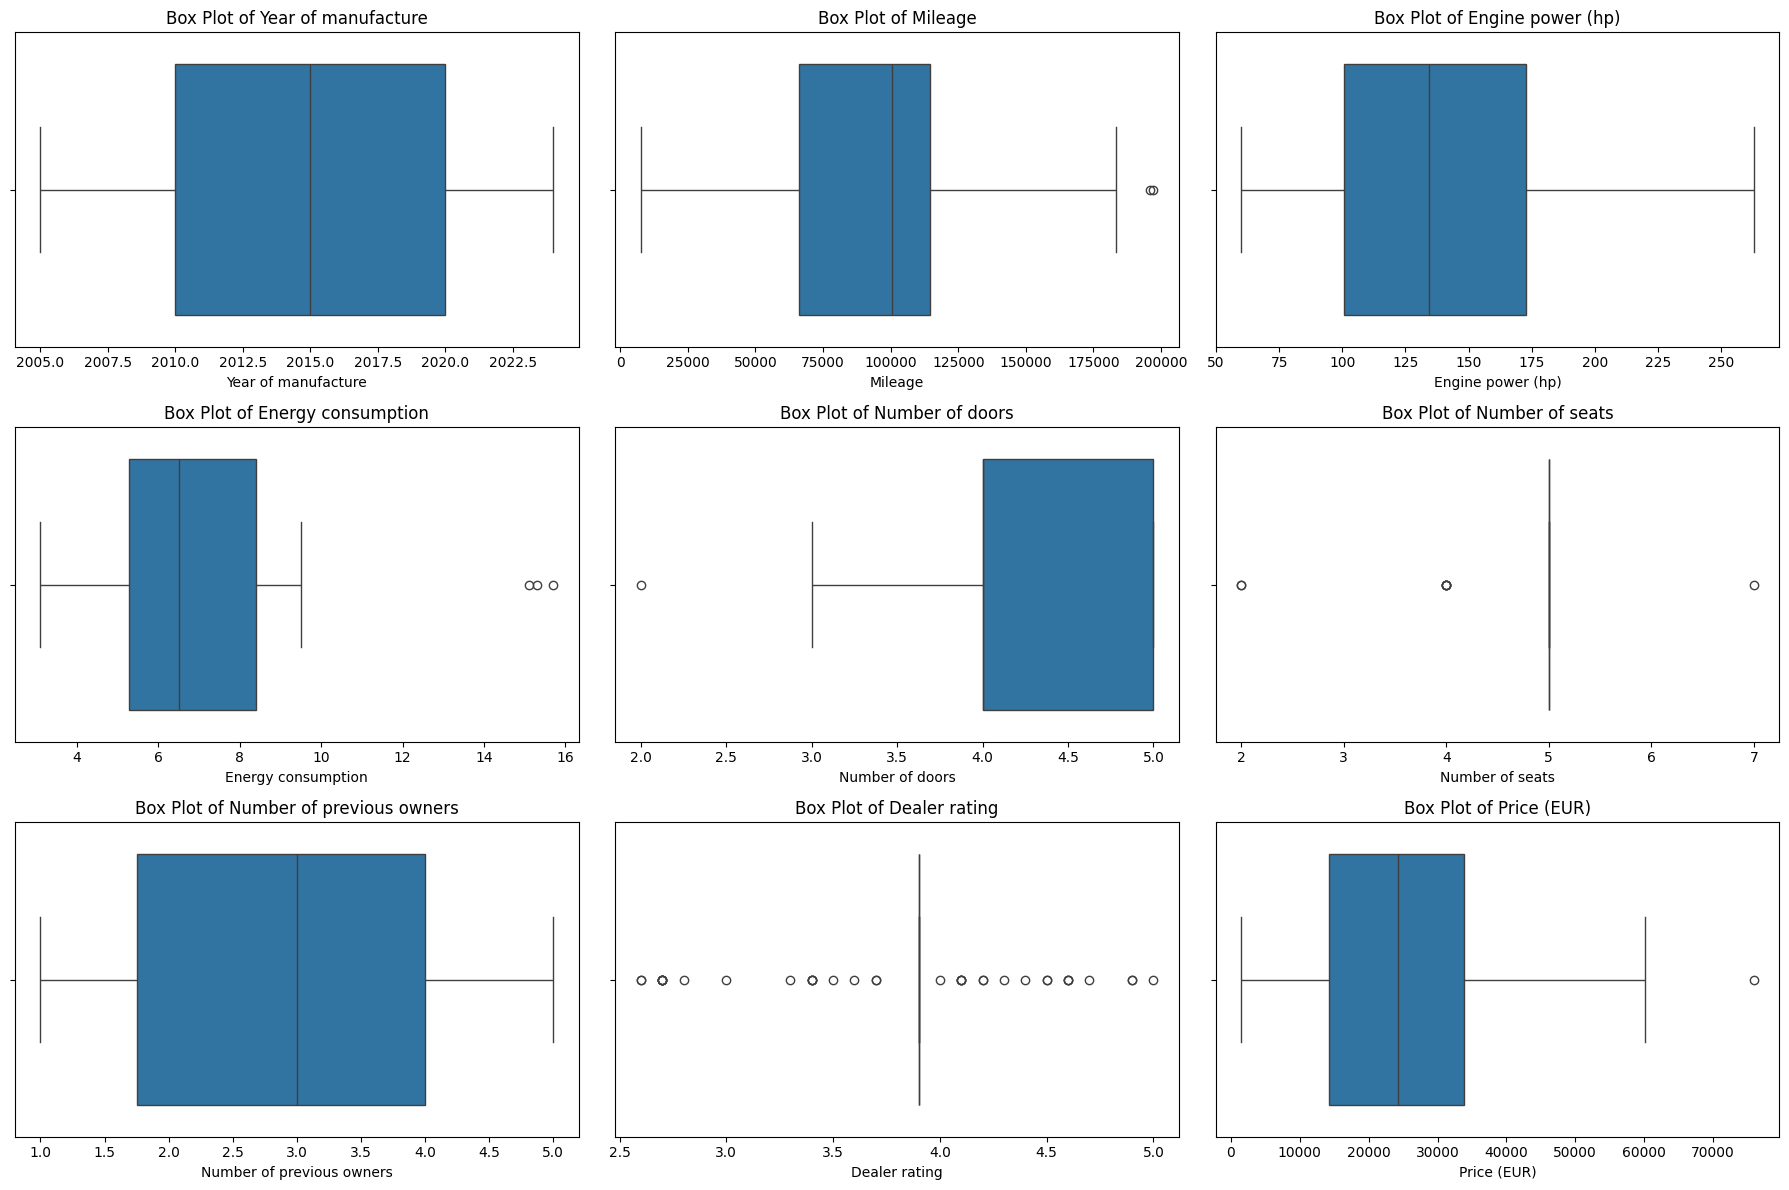

In [154]:
def box_plot(cols):
    import math
    n = len(cols)

    # Determine grid size automatically (3 columns per row)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(x=data[col], ax=axes[i])
        axes[i].set_title(f'Box Plot of {col}')

    # Hide unused axes if columns don't fill the grid
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
box_plot(numerical_cols[:9])

#### **Categorical Encoding**
##### **Mean-Target Encoding**

For Mean Target_Encoding we will take variable  with many unique variable.
- Calculate the Mean Target (Price) for each category
- Replace category in with its corresponding Mean Price

In [155]:
#
extra=data['Extras']
print(extra)# Extra encoding
extrax_mean_price= data.groupby('Extras')['Price (EUR)'].mean()

# # Mapping
data['Encoded_Extras'] = data['Extras'].map(extrax_mean_price)

data.drop('Extras', axis=1, inplace=True)

# print(data.columns)
# print(f'Anz_Rows:{len(data)}')
# print(f'Anz_Columns:{len(data.columns)}')





KeyError: 'Extras'

#### **One-Hot Encoding**

We use this method for variable that, they don't have too many cardinality 


In [ ]:
# Prepare for One-Hot Encoding
# Ensure only existing nominal columns are selected
nominal_cols = [col for col in nominal_features if col in data.columns]

print(f'Nominal Columns for One-Hot Encoding: {data[nominal_cols].head()}')

# One-Hot Encoding for nominal features
encoder= OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the nominal features
encoded_nominal_array= encoder.fit_transform(data[nominal_cols])

# Create a DataFrame with the encoded features
# convert the encoded array to a DataFrame
encoded_df= pd.DataFrame( encoded_nominal_array, 
                         columns=encoder.get_feature_names_out(nominal_cols)
   )

# Concatenate the original DataFrame (excluding nominal features) with the encoded DataFrame
# Drop the original nominal features from the data and merge with encoded features
nominal_features_encoded= data.drop(columns=nominal_cols).reset_index(drop=True)
#data_encoded= pd.concat([nominal_features_encoded, encoded_df], axis=1)

categorical_cols = data_encoded.select_dtypes(include=['object']).columns
#print(categorical_cols)

#print(data_encoded.head())



Nominal Columns for One-Hot Encoding:    Brand and model Fuel type Transmission type Trim level / Equipment line  \
55    Renault Clio  electric         automatic                        Base   
88   Skoda Octavia    diesel         automatic                   Trendline   
26     Hyundai i10    petrol            manual                     Premium   
42    Skoda Kodiaq    hybrid         automatic                     Comfort   
69         Audi A3    petrol            manual                   Trendline   

      Origin   Color Air conditioning / Climate control Transmission  \
55  trade-in   black          automatic climate control    automatic   
88   private   green                              no AC    automatic   
26   private   beige                              no AC       manual   
42    dealer    blue                          manual AC    automatic   
69    dealer  silver          dual-zone climate control       manual   

     Drive type Interior equipment / Interior design Acciden

In [ ]:
# One-Hot Encoding for nominal features
encoder= OneHotEncoder(sparse_output=False, drop='first')

# Fit and transform the nominal features
encoded_ordinal_array= encoder.fit_transform(data[ordinal_cols])
print(encoded_ordinal_array)
print(data[ordinal_cols].head())


# Create a DataFrame with the encoded features
# convert the encoded array to a DataFrame
encoded_ordinal_df= pd.DataFrame( encoded_ordinal_array, 
                         columns=encoder.get_feature_names_out(ordinal_cols)
   )

# Concatenate the original DataFrame (excluding nominal features) with the encoded DataFrame
# Drop the original nominal features from the data and merge with encoded features
ordinal_features_encoded= data.drop(columns=ordinal_cols).reset_index(drop=True)

#data_encoded= pd.concat([ordinal_features_encoded, encoded_ordinal_df], axis=1)
#print(data_encoded.columns)


[[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 1. 0.]
 ...
 [1. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]]
   Vehicle condition Inspection status (TÜV/HU) Body & paint Panel gaps & fit  \
55        acceptable              Expiring soon         Poor  Slightly uneven   
88        acceptable                    Unknown         Good           Uneven   
26              good                    Unknown         Fair             Even   
42         very good              Expiring soon    Excellent  Slightly uneven   
69              good              Expiring soon         Fair           Uneven   

       Windows & lights Tires & wheels Undercarriage & edges  \
55  Cracked or yellowed            New            Oil stains   
88      Minor scratches            New            Oil stains   
26  Cracked or yellowed        Damaged            Minor rust   
42                Clear        Damaged            Minor rust   
69  Cracked or yellowed    Uneven wea

In [ ]:
#print("Object columns:", data_encoded.select_dtypes(include=["object"]).columns.tolist())
print(data_encoded.dtypes)



Brand and model         object
Year of manufacture      int64
Mileage                  int64
Engine power (hp)        int64
Fuel type               object
                        ...   
Trunk_Moisture         float64
Trunk_Rust             float64
Odor_Pet odor          float64
Odor_Smoke             float64
Odor_Unknown           float64
Length: 62, dtype: object


In [ ]:
#print(data_encoded.select_dtypes(include="object"))


   Brand and model Fuel type Transmission type Trim level / Equipment line  \
0     Renault Clio  electric         automatic                        Base   
1    Skoda Octavia    diesel         automatic                   Trendline   
2      Hyundai i10    petrol            manual                     Premium   
3     Skoda Kodiaq    hybrid         automatic                     Comfort   
4          Audi A3    petrol            manual                   Trendline   
..             ...       ...               ...                         ...   
75  Hyundai Tucson  electric         automatic                  Excellence   
76    BMW 3 Series    petrol         automatic                     Premium   
77      Opel Corsa    petrol            manual                  Excellence   
78         Audi A4    hybrid         automatic                  Excellence   
79    Renault Clio    diesel            manual                       Sport   

      Origin Category / Vehicle type   Color  \
0   trade-in   

#### **CHECKPOINT**

In [156]:


# 1. Alle kategorialen Spalten finden
categorical_cols = data.select_dtypes(include='object').columns

# 2. One-Hot Encoder
encoder = OneHotEncoder(sparse_output=False, drop='first')

# 3. Kategorien encodieren
encoded_array = encoder.fit_transform(data[categorical_cols])

# 4. DataFrame daraus erzeugen
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(categorical_cols))

# 5. Alte Spalten löschen und neue anfügen
numeric_df = data.drop(columns=categorical_cols).reset_index(drop=True)

data_encoded = pd.concat([numeric_df, encoded_df], axis=1)

print(f'Nber: {len(data_encoded.columns)} columns after encoding.')
print(data_encoded.select_dtypes(include="object"))

print(data_encoded.head())
print(data_encoded.dtypes)


Nber: 133 columns after encoding.
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79]

[80 rows x 0 columns]
   Year of manufacture  Mileage  Engine power (hp)  Energy consumption  \
0                 2009   110639                199                15.7   
1                 2015    77371                 75                 8.1   
2                 2015    94588                 60                 7.8   
3                 2014    40473                116                 5.5   
4                 2005   115689                180                 5.4   

   Number of doors  Number of seats  Number of previous owners  Dealer rating  \
0                4                5                          2         

In [ ]:
%store data_encoded


Stored 'data_encoded' (DataFrame)
